In [2]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("awsaf49/asvpoof-2019-dataset")

print("Path to dataset files:", path)

c:\Users\eglha\anaconda3\envs\torch_gen\lib\site-packages\requests\__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
c:\Users\eglha\anaconda3\envs\torch_gen\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\eglha\.cache\kagglehub\datasets\awsaf49\asvpoof-2019-dataset\versions\1


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohammedabdeldayem/avsspoof-2021")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\eglha\.cache\kagglehub\datasets\mohammedabdeldayem\avsspoof-2021\versions\7


In [4]:
import os
import random
from huggingface_hub import hf_hub_download
import numpy as np
import pandas as pd
from tqdm import tqdm
import glob

import librosa

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from transformers import (
    Wav2Vec2Model
)
import kagglehub
from huggingface_hub import hf_hub_download

from sklearn.metrics import (
    roc_curve,
    confusion_matrix,
    classification_report
)

from scipy.optimize import brentq
from scipy.interpolate import interp1d

import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {DEVICE}")

torch.backends.cudnn.benchmark = True

# ============================================================
# OUTPUT DIRECTORIES
# ============================================================


RESULTS_DIR = "wav2vec2_4_results"
CACHE_DIR = "wav2vec2_4_cache"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

# ============================================================
# HYPERPARAMETERS
# ============================================================

SR = 16000
MAX_LEN = 4 * SR
BATCH_SIZE = 16
EPOCHS = 5
LR = 1e-5
NUM_WORKERS = 4

# ============================================================
# DATASET PATHS
# ============================================================

BASE_2019 = r"C:\Users\eglha\.cache\kagglehub\datasets\awsaf49\asvpoof-2019-dataset\versions\1\LA\LA"

TRAIN_AUDIO_DIR = os.path.join(
    BASE_2019,
    "ASVspoof2019_LA_train",
    "flac"
)

DEV_AUDIO_DIR = os.path.join(
    BASE_2019,
    "ASVspoof2019_LA_dev",
    "flac"
)

TRAIN_PROTOCOL = os.path.join(
    BASE_2019,
    "ASVspoof2019_LA_cm_protocols",
    "ASVspoof2019.LA.cm.train.trn.txt"
)

DEV_PROTOCOL = os.path.join(
    BASE_2019,
    "ASVspoof2019_LA_cm_protocols",
    "ASVspoof2019.LA.cm.dev.trl.txt"
)

# ============================================================
# 2021 DF
# ============================================================

BASE_2021 = os.path.join(
    "datasets",
    "ASVspoof2021_DF_eval_part00",
    "ASVspoof2021_DF_eval"
)

TEST_AUDIO_DIR = os.path.join(
    BASE_2021,
    "flac"
)



DF_KEY_FILE = os.path.join(
    "keys",
    "DF",
    "CM",
    "trial_metadata.txt"
)

TEST_PROTOCOL = DF_KEY_FILE

# ============================================================
# SEED
# ============================================================

def seed_everything(seed=42):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)

seed_everything()

# ============================================================
# EER
# ============================================================

def compute_eer(y_true, y_score):

    fpr, tpr, _ = roc_curve(
        y_true,
        y_score
    )

    eer = brentq(
        lambda x: 1. - x - interp1d(fpr, tpr)(x),
        0.,
        1.
    )

    return eer * 100

# ============================================================
# CACHE AUDIO
# ============================================================

import soundfile as sf

def process_audio(audio_path):

    try:

        # ============================================
        # TRY SOUNDFile FIRST
        # ============================================

        waveform, sr = sf.read(audio_path)

        # stereo -> mono
        if len(waveform.shape) > 1:

            waveform = waveform.mean(axis=1)

        # resample if needed
        if sr != SR:

            waveform = librosa.resample(
                waveform,
                orig_sr=sr,
                target_sr=SR
            )

    except Exception as e:

        try:

            # ============================================
            # FALLBACK TO LIBROSA
            # ============================================

            waveform, sr = librosa.load(
                audio_path,
                sr=SR,
                mono=True
            )

        except Exception as e2:

            print(f"FAILED TO LOAD: {audio_path}")

            return None

    # ============================================
    # PAD / TRUNCATE
    # ============================================

    if len(waveform) > MAX_LEN:

        waveform = waveform[:MAX_LEN]

    else:

        waveform = np.pad(
            waveform,
            (0, MAX_LEN - len(waveform))
        )

    waveform = torch.tensor(
        waveform
    ).float()

    return waveform
# ============================================================
# PRECACHE AUDIO
# ============================================================

def cache_audio_dataset(audio_dir):

    print(f"\nCaching: {audio_dir}")

    files = [
        f for f in os.listdir(audio_dir)
        if f.endswith(".flac")
    ]

    for file in tqdm(files):

        cache_path = os.path.join(
            CACHE_DIR,
            file.replace(".flac", ".pt")
        )

        if os.path.exists(cache_path):
            continue

        audio_path = os.path.join(
            audio_dir,
            file
        )

        waveform = process_audio(
            audio_path
        )
        
        if waveform is None:
        
            continue
        
        torch.save(
            waveform,
            cache_path
        )
# ============================================================
# DATASET
# ============================================================

class ASVSpoofDataset(Dataset):

    def __init__(
        self,
        protocol_file,
        dataset_type="2019"
    ):

        self.data = []

        with open(protocol_file, "r") as f:

            lines = f.readlines()

        # ============================================
        # 2019
        # ============================================

        if dataset_type == "2019":

            for line in lines:

                parts = line.strip().split()

                file_id = parts[1]

                label = parts[-1]

                label = (
                    1 if label == "bonafide"
                    else 0
                )

                self.data.append(
                    (file_id, label)
                )

        # ============================================
        # 2021
        # ============================================

        
        else:
            for line in lines:
                parts = line.strip().split()
        
                # Expected format:
                # speaker  file_id  codec  source  attack  label  ...
                # Example:
                # LA_0023 DF_E_2000011 nocodec asvspoof A14 spoof notrim ...
        
                if len(parts) < 6:
                    continue
        
                file_id = parts[1]      # DF_E_2000011
                label_str = parts[5]    # spoof / bonafide
        
                if label_str not in ["spoof", "bonafide"]:
                    continue
        
                label = 1 if label_str == "bonafide" else 0
        
                self.data.append((file_id, label))


    def __len__(self):

        return len(self.data)

    def __getitem__(self, idx):

        file_id, label = self.data[idx]

        cache_path = os.path.join(
            CACHE_DIR,
            file_id + ".pt"
        )

        if not os.path.exists(cache_path):
        
            return self.__getitem__(
                random.randint(0, len(self.data)-1)
            )
        
        waveform = torch.load(cache_path)

        return waveform, torch.tensor(label).long()

# ============================================================
# MODEL
# ============================================================

class Wav2Vec2Deepfake(nn.Module):

    def __init__(self):

        super().__init__()

        self.wav2vec = Wav2Vec2Model.from_pretrained(
            "facebook/wav2vec2-base",
            use_safetensors=True
        )

        hidden_size = (
            self.wav2vec.config.hidden_size
        )

        # ============================================
        # FREEZE MOST OF MODEL
        # ============================================

        for param in self.wav2vec.parameters():

            param.requires_grad = False

        # ============================================
        # UNFREEZE LAST 2 ENCODER LAYERS
        # ============================================

        for layer in self.wav2vec.encoder.layers[-2:]:

            for param in layer.parameters():

                param.requires_grad = True

        # ============================================
        # CLASSIFIER
        # ============================================

        self.classifier = nn.Sequential(

            nn.Linear(hidden_size, 256),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(256, 2)
        )

    def forward(self, x):

        outputs = self.wav2vec(
            x
        )

        hidden_states = (
            outputs.last_hidden_state
        )

        pooled = hidden_states.mean(
            dim=1
        )

        logits = self.classifier(
            pooled
        )

        return logits



# ============================================================
# EVALUATE
# ============================================================

def evaluate(model, loader):

    model.eval()

    y_true = []

    y_scores = []

    y_pred = []

    with torch.no_grad():

        for waveforms, labels in tqdm(loader):

            waveforms = waveforms.to(
                DEVICE,
                non_blocking=True
            )

            outputs = model(
                waveforms
            )

            probs = torch.softmax(
                outputs,
                dim=1
            )[:, 1]

            preds = (
                probs >= 0.5
            ).long()

            y_scores.extend(
                probs.cpu().numpy()
            )

            y_pred.extend(
                preds.cpu().numpy()
            )

            y_true.extend(
                labels.numpy()
            )

    eer = compute_eer(
        y_true,
        y_scores
    )

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    report = classification_report(
        y_true,
        y_pred,
        digits=4
    )

    return {

        "eer": eer,

        "y_true": y_true,

        "y_scores": y_scores,

        "y_pred": y_pred,

        "confusion_matrix": cm,

        "report": report
    }


# ============================================================
# FIND LATEST CHECKPOINT
# ============================================================



Using device: cuda


In [5]:
 
# ============================================================
# MAIN
# ============================================================

def main():

    wav2vec_name='best_model.pth'
    latest_checkpoint=hf_hub_download(
        repo_id='rde6mn/no_aug_w2v_4s',
        filename=wav2vec_name)
    final_checkpoint = latest_checkpoint
    # ============================================
    # CACHE AUDIO
    # ============================================

    cache_audio_dataset(
        TRAIN_AUDIO_DIR
    )

    #cache_audio_dataset(DEV_AUDIO_DIR)

    #cache_audio_dataset(TEST_AUDIO_DIR)

    # ============================================
    # DATASETS
    # ============================================

    # ============================================
    # FULL 2019 DATASET
    # ============================================
    
    full_dataset = ASVSpoofDataset(
        TRAIN_PROTOCOL,
        dataset_type="2019"
    )
    
    # ============================================
    # TRAIN / VAL / TEST SPLIT
    # ============================================
    
    train_size = int(0.8 * len(full_dataset))
    
    val_size = int(0.1 * len(full_dataset))
    
    test_size = (
        len(full_dataset)
        - train_size
        - val_size
    )
    
    train_dataset, val_dataset, test_dataset = random_split(
        full_dataset,
        [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(42)
    )


    
    # ============================================
    # AUGMENTATION SETTINGS
    # ============================================
    
    train_dataset.dataset.training = False
    

    
    # ============================================
    # DATALOADERS
    # ============================================
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=True
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=True
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=True
    )

    # ============================================
    # MODEL
    # ============================================

    model = Wav2Vec2Deepfake().to(
        DEVICE
    )

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(

        filter(
            lambda p: p.requires_grad,
            model.parameters()
        ),

        lr=LR
    )
    model.load_state_dict(torch.load(final_checkpoint, map_location=DEVICE)["model_state_dict"])


# ============================================================

if __name__ == "__main__":

    main()


Caching: C:\Users\eglha\.cache\kagglehub\datasets\awsaf49\asvpoof-2019-dataset\versions\1\LA\LA\ASVspoof2019_LA_train\flac


Loading weights: 100%|██████████| 211/211 [00:00<00:00, 11870.72it/s]
[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.bias               | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
c:\Users\eglha\anaconda3\envs\torch_gen\lib\site-packages\torch\cuda\__init__.py:235: UserWarning: 
NVIDIA GeForce RTX 5070 with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 s

In [6]:

from huggingface_hub import hf_hub_download

model = Wav2Vec2Deepfake().to(DEVICE)

wav2vec_name='best_model.pth'
latest_checkpoint=hf_hub_download(
    repo_id='rde6mn/no_aug_w2v_4s',
    filename=wav2vec_name
)
checkpoint = torch.load(latest_checkpoint, map_location=DEVICE)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad,model.parameters()),lr=LR)   
model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])




Loading weights: 100%|██████████| 211/211 [00:00<00:00, 18439.00it/s]
[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.bias               | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
C:\Users\eglha\AppData\Local\Temp\ipykernel_16076\3016784762.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during un

In [7]:
class ASVSpoofDataset(Dataset):
    def __init__(
        self,
        protocol_file,
        dataset_type="2019"
    ):
        self.data = []
        with open(protocol_file, "r") as f:
            lines = f.readlines()
        # ============================================
        # 2019
        # ============================================
        if dataset_type == "2019":
            for line in lines:
                parts = line.strip().split()
                file_id = parts[1]
                label = parts[-1]
                label = (
                    1 if label == "bonafide"
                    else 0
                )
                self.data.append(
                    (file_id, label)
                )
        # ============================================
        # 2021
        # ============================================
        else:
            for line in lines:
                parts = line.strip().split()
                # Expected format:
                # speaker  file_id  codec  source  attack  label  ...
                # Example:
                # LA_0023 DF_E_2000011 nocodec asvspoof A14 spoof notrim ...
                if len(parts) < 6:
                    continue
                file_id = parts[1]      # DF_E_2000011
                label_str = parts[5]    # spoof / bonafide
                if label_str not in ["spoof", "bonafide"]:
                    continue
                label = 1 if label_str == "bonafide" else 0
                self.data.append((file_id, label))
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        file_id, label = self.data[idx]
        cache_path = os.path.join(
            CACHE_DIR,
            file_id + ".pt"
        )


        waveform = torch.load(cache_path)
        return waveform, torch.tensor(label).long()

In [8]:
for fname in os.listdir(CACHE_DIR):
    if fname.startswith("LA_"):
        new = fname.replace("LA_", "LA_T_")
        os.rename(os.path.join(CACHE_DIR, fname),
                  os.path.join(CACHE_DIR, new))

In [9]:
full_dataset = ASVSpoofDataset(
    TRAIN_PROTOCOL,
    dataset_type="2019"
)

In [10]:
full_dataset[1]

C:\Users\eglha\AppData\Local\Temp\ipykernel_16076\2607915091.py:54: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  waveform = torch.load(cache_path)


FileNotFoundError: [Errno 2] No such file or directory: 'wav2vec2_4_cache\\LA_T_1271820.pt'

In [ ]:
def make_spectrogram(dataset_item, sr=20):
    waveform, label = dataset_item
    # Compute the spectrogram
    S = librosa.stft(waveform.numpy())
    S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)

    # Plot the spectrogram
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Spectrogram for label: {"bonafide" if label.item() == 0 else "spoof"}')
    plt.tight_layout()
    plt.show()

C:\Users\eglha\AppData\Local\Temp\ipykernel_22284\2607915091.py:54: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  waveform = torch.load(cache_path)


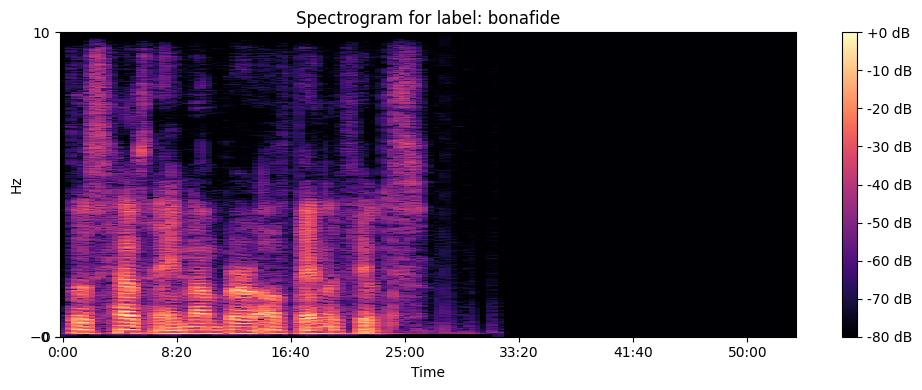

In [ ]:
random_item=full_dataset[random.randint(0, len(full_dataset)-1)]
make_spectrogram(random_item)

In [ ]:
data_loader = DataLoader(
        full_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=True
    )

In [ ]:
print(BATCH_SIZE)

16


In [ ]:
print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:

def predict(model, dataloader, pred_limit=None):
    with torch.no_grad():
        model.eval()
        predictions = []
        i=0
        for waveform, label in enumerate(dataloader):

            waveform = waveform.to(DEVICE)  # Add batch dimension
            print("waveform device:", waveform.device)
            print("model device:", next(model.parameters()).device)

            outputs = model(waveform)
            probs = torch.softmax(outputs, dim=1)[:, 1]  # Get probability of class 1 (bonafide)
            predictions.append((probs.item(), label.item()))
            i+=1
            if pred_limit is not None and i >= pred_limit:
                break
    return predictions
    

predictions = predict(model, data_loader, pred_limit=10)


NameError: name 'model' is not defined

In [ ]:

print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))


CUDA: True
GPU: NVIDIA GeForce RTX 5070
